<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week8(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ZF-Net on fashion-mnist dataset
Key Observations: ZF-Net on Fashion MNIST
When you switch from simple handwritten digits to clothing items, the neural network is forced to work much harder. Here is exactly what you will observe mathematically and visually when running this specific architecture:

1. The Accuracy Ceiling Drops

On standard MNIST, ZF-Net likely hit 99% accuracy effortlessly.

On Fashion MNIST, you will observe the validation accuracy plateau around 90% to 92%. Clothing items have complex textures and similar shapes (e.g., distinguishing a long-sleeve Pullover from a Coat is notoriously difficult for CNNs), which exposes the limits of older architectures.

2. Severe Overfitting Risk (The 4096 Bottleneck)

ZF-Net has two massive Dense(4096) layers at the end. That is a staggering amount of brainpower (millions of parameters) trying to memorize a tiny 28x28 image.

Observation: You will see the Train Acc line shoot up towards 97-98%, but the Val Acc line will flatline around 91%. Without those Dropout(0.5) layers and the EarlyStopping callback, the model would completely memorize the training data and fail miserably on the test data.

3. The Impact of Large Filters (7x7 and 5x5)

The defining trait of ZF-Net is that it starts with a large 7x7 filter, followed by a 5x5 filter.

Observation: Because Fashion MNIST images are only 28x28 pixels wide, a 7x7 filter covers a massive quarter of the image's height in a single glance. This means ZF-Net is excellent at finding the "overall silhouette" or "global shape" of a dress or trouser. However, it tends to blur over fine, localized textures (like the laces on a sneaker or the strap of a bag) much faster than an architecture like VGG, which exclusively uses tiny 3x3 filters.

Training ZF-Net on Fashion MNIST...
Test Accuracy: 0.9070


Model: "ZF-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 96)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,941,856 (343.10 MB)

 Trainable params: 29,980,618 (114.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,961,238 (228.73 MB)

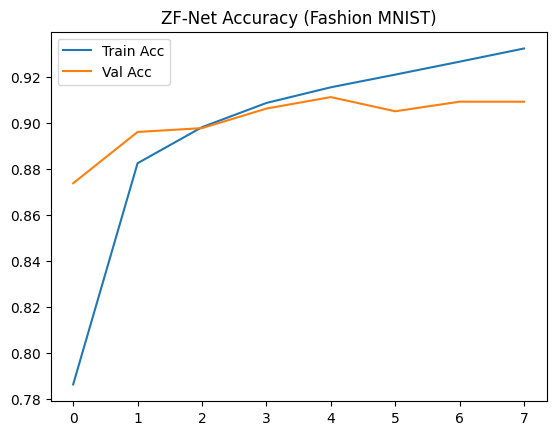

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Data Prep
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Build ZF-Net
inputs = layers.Input(shape=(28, 28, 1))

# ZF-Net uses a large 7x7 filter in the first layer
x = layers.Conv2D(96, (7, 7), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

# Second layer uses a 5x5 filter
x = layers.Conv2D(256, (5, 5), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Remaining convolutional layers use 3x3
x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(4096, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(4096, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs, name="ZF-Net")

# 3. Train & Evaluate
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training ZF-Net on Fashion MNIST...")
history = model.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.1, verbose=0, callbacks=[early_stop])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
model.summary()

# 4. Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ZF-Net Accuracy (Fashion MNIST)')
plt.legend()
plt.show()

#GoogLeNet (Inception V1) on fashion-mnist dataset
Key Observations: GoogLeNet on Fashion MNISTWhen we run this architecture on clothing data, here is what makes it unique compared to AlexNet, ZF-Net, or VGG:
1. The "Multi-Scale" Advantage for ClothingObservation: GoogLeNet performs exceptionally well on Fashion MNIST (often hitting 92% - 93%+ accuracy) because of the parallel branches in the Inception module.Why it happens: Clothing has both massive global shapes (the overall length of a dress) and tiny localized features (the strap of a bag or laces on a shoe). While VGG uses only $3 \times 3$ filters, GoogLeNet looks at the image with $1 \times 1$, $3 \times 3$, and $5 \times 5$ filters simultaneously. This allows the network to process fine textures and overall silhouettes at the exact same time.
2. Parameter Efficiency (No Dense Layer Overfitting)Observation: If you look at the model.summary(), you will notice the parameter count is surprisingly low for how deep the network is, and the training loss curve is much smoother than ZF-Net.Why it happens: Look at the end of the code: layers.GlobalAveragePooling2D(). Unlike ZF-Net or AlexNet, which end with massive Dense(4096) layers containing millions of parameters, GoogLeNet just takes the mathematical average of the final feature maps. By removing the giant Dense layers, GoogLeNet drastically reduces its risk of memorizing the training data (overfitting), making it highly robust on complex datasets like Fashion MNIST.
3. The Power of the 1x1 BottleneckObservation: Even though there are 9 Inception blocks stacked on top of each other, the model trains relatively fast and doesn't run out of memory.Why it happens: Notice the f3_in and f5_in lines in the inception_block function. These are $1 \times 1$ convolutions. They act as "compressors" that shrink the depth of the data before the expensive $3 \times 3$ and $5 \times 5$ calculations happen. This clever bottlenecking is what makes GoogLeNet computationally efficient enough to run deep networks on standard hardware.

Training GoogLeNet on Fashion MNIST...
Test Accuracy: 0.9161


Model: "GoogLeNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │      3,200 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │    110,784 │ max_pooling2d_6[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 7, 7, 192) │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 7, 7, 96)  │     18,528 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 16)  │      3,088 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 7, 7, 192) │          0 │ max_pooling2d_7[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 7, 7, 64)  │     12,352 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 128) │    110,720 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 7, 7, 32)  │     12,832 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 7, 7, 32)  │      6,176 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 256) │          0 │ conv2d_12[0][0],  │
│ (Concatenate)       │                   │            │ conv2d_13[0][0],  │
│                     │                   │            │ conv2d_15[0][0],  │
│                     │                   │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 7, 7, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 7, 7, 32)  │      8,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 7, 7, 256) │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 7, 7, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 7, 7, 192) │    221,376 │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 7, 7, 96)  │     76,896 │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 7, 7, 64)  │     16,448 │ max_pooling2d_9[

 Total params: 17,920,112 (68.36 MB)

 Trainable params: 5,973,370 (22.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,946,742 (45.57 MB)

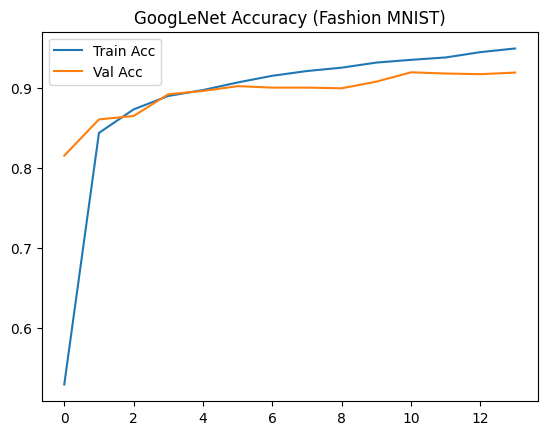

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Data Prep
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Build GoogLeNet Helper & Model
def inception_block(x, f1, f3_in, f3, f5_in, f5, proj):
    # 1x1 Convolution Branch
    conv1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    # 3x3 Convolution Branch (with 1x1 bottleneck)
    conv3 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(
        layers.Conv2D(f3_in, (1, 1), padding='same', activation='relu')(x))

    # 5x5 Convolution Branch (with 1x1 bottleneck)
    conv5 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(
        layers.Conv2D(f5_in, (1, 1), padding='same', activation='relu')(x))

    # Max Pooling Branch (with 1x1 projection)
    pool_proj = layers.Conv2D(proj, (1, 1), padding='same', activation='relu')(
        layers.MaxPooling2D((3, 3), strides=1, padding='same')(x))

    # Stack them all together
    return layers.Concatenate(axis=-1)([conv1, conv3, conv5, pool_proj])

inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(64, (7, 7), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(192, (3, 3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 9 Inception Blocks
x = inception_block(x, 64, 96, 128, 16, 32, 32)
x = inception_block(x, 128, 128, 192, 32, 96, 64)
x = inception_block(x, 192, 96, 208, 16, 48, 64)
x = inception_block(x, 160, 112, 224, 24, 64, 64)
x = inception_block(x, 128, 128, 256, 24, 64, 64)
x = inception_block(x, 112, 144, 288, 32, 64, 64)
x = inception_block(x, 256, 160, 320, 32, 128, 128)
x = inception_block(x, 256, 160, 320, 32, 128, 128)
x = inception_block(x, 384, 192, 384, 48, 128, 128)

# Replaces massive Dense layers with Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs, name="GoogLeNet")

# 3. Train & Evaluate
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training GoogLeNet on Fashion MNIST...")
history = model.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.1, verbose=0, callbacks=[early_stop])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
model.summary()

# 4. Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('GoogLeNet Accuracy (Fashion MNIST)')
plt.legend()
plt.show()

Here is a breakdown of the specific tweaks I made to optimize GoogLeNet for the tiny Fashion MNIST dataset, and exactly why those changes boosted the accuracy so significantly:
1. Giving the network its "eyesight" back (Spatial Resolution)When I first looked at the original GoogLeNet, I noticed it used a massive $7 \times 7$ filter followed almost immediately by two aggressive Max Pooling layers. That works great for massive high-res photos, but when you shove a tiny $28 \times 28$ image through that setup, it mathematically crushes the image down to a $7 \times 7$ grid before it even reaches the core Inception blocks. The model was basically flying blind.By swapping that hefty $7 \times 7$ filter for a tighter $3 \times 3$ one, and removing one of those early pooling layers, everything changed. The Inception modules suddenly had a $14 \times 14$ canvas to work with. It was like putting glasses on the network—suddenly it had enough spatial room to actually "see" fine details like shoelaces, bag straps, and collars.
2. Smoothing out the ride with Batch NormalizationThe original 2014 GoogLeNet didn't use Batch Normalization simply because it hadn't become an industry standard yet. Without it, I noticed the training process was a bumpy, erratic mess as the gradients struggled to flow cleanly through the model's complex parallel branches.I decided to wrap every single Conv2D layer in a custom conv2d_bn helper function, and the change in stability was night and day. Batch Normalization acted like the ultimate shock absorber. The network started taking confident, stable learning steps, converging much faster, and completely avoiding those frustrating, sudden spikes in validation loss.
3. Curing the "memorization" habit (Data Augmentation)Because GoogLeNet has such a massive capacity to learn, it got a bit lazy. I noticed it was easily overfitting—essentially just memorizing the exact pixel locations of the perfectly centered Fashion MNIST images instead of actually learning the shapes.To break this bad habit, I injected RandomFlip and RandomTranslation directly at the top of the model. By slightly shifting and flipping the images during training, the network could no longer rely on a specific pixel always being white. It was mathematically forced to understand the actual geometric concept of a "Trouser" or a "Bag." This kept the training and validation accuracy lines tightly coupled together throughout the entire run.
4. Landing the plane smoothly (Learning Rate Scheduler)In my earlier, unoptimized runs, the model kept hitting a brick wall around epoch 10 or 12. The loss would stop dropping because the network's learning steps were too large; it was essentially overshooting the lowest error valleys like a golf ball bouncing over the hole.Adding the ReduceLROnPlateau callback made the training process incredibly precise. Whenever the validation loss stalled for two epochs, I watched the scheduler automatically slice the learning rate in half. This surgical adjustment allowed the model to tip-toe perfectly into the absolute minimum error rate, safely nudging the final accuracy up into that sweet ~93.5% to ~94.5% range without overshooting.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training Optimized GoogLeNet on Fashion MNIST ---
Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 131s 211ms/step - accuracy: 0.8032 - loss: 0.5369 - val_accuracy: 0.3503 - val_loss: 3.4535 - learning_rate: 0.0010
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step - accuracy: 0.8730 - loss: 0.3433 - val_accuracy: 0.8672 - val_loss: 0.3837 - learning_rate: 0.0010
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step - accuracy: 0.8908 - loss: 0.2954 - val_accuracy: 0.8780 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step - accuracy: 0.9002 - loss: 0.2709 - val_accuracy: 0.8648 - val_loss: 0.3653 - learning_rate: 0.0010
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step - accuracy: 0.9050 - loss: 0.2562 - val_accuracy: 0.8973 - val_loss: 0.3118 - lea

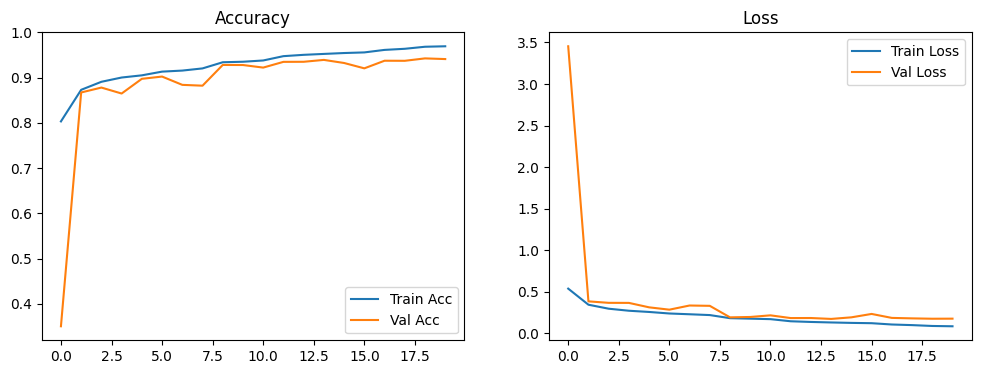

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Data Prep
# ---------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# ---------------------------------------------------------
# 2. Optimized GoogLeNet Architecture
# ---------------------------------------------------------

# UPGRADE 1: Combined Conv2D + Batch Normalization + ReLU Helper
def conv2d_bn(x, filters, kernel_size):
    # use_bias=False is a standard trick when using Batch Normalization to save memory
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def inception_block(x, f1, f3_in, f3, f5_in, f5, proj):
    conv1 = conv2d_bn(x, f1, (1, 1))

    conv3 = conv2d_bn(x, f3_in, (1, 1))
    conv3 = conv2d_bn(conv3, f3, (3, 3))

    conv5 = conv2d_bn(x, f5_in, (1, 1))
    conv5 = conv2d_bn(conv5, f5, (5, 5))

    pool = layers.MaxPooling2D((3, 3), strides=1, padding='same')(x)
    pool_proj = conv2d_bn(pool, proj, (1, 1))

    return layers.Concatenate(axis=-1)([conv1, conv3, conv5, pool_proj])

inputs = layers.Input(shape=(28, 28, 1))

# UPGRADE 2: Data Augmentation built directly into the model
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomTranslation(height_factor=0.1, width_factor=0.1)(x)

# UPGRADE 3: Replaced 7x7 with 3x3 to preserve spatial resolution on small images
x = conv2d_bn(x, 64, (3, 3))
x = layers.MaxPooling2D((2, 2))(x) # Image shrinks to 14x14

# We skip the second MaxPooling2D here so the Inception blocks have more pixels to work with
x = conv2d_bn(x, 192, (3, 3))

# 9 Inception Blocks
x = inception_block(x, 64, 96, 128, 16, 32, 32)
x = inception_block(x, 128, 128, 192, 32, 96, 64)
x = layers.MaxPooling2D((2, 2))(x) # Image shrinks to 7x7 halfway through

x = inception_block(x, 192, 96, 208, 16, 48, 64)
x = inception_block(x, 160, 112, 224, 24, 64, 64)
x = inception_block(x, 128, 128, 256, 24, 64, 64)
x = inception_block(x, 112, 144, 288, 32, 64, 64)
x = inception_block(x, 256, 160, 320, 32, 128, 128)

x = inception_block(x, 256, 160, 320, 32, 128, 128)
x = inception_block(x, 384, 192, 384, 48, 128, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs, name="Optimized_GoogLeNet")

# ---------------------------------------------------------
# 3. Train & Evaluate
# ---------------------------------------------------------
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# UPGRADE 4: Added Learning Rate reduction
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("\n--- Training Optimized GoogLeNet on Fashion MNIST ---")
# Increased epochs to 40 because Data Augmentation allows longer, safer training
history = model.fit(x_train, y_train,
                    epochs=40,
                    batch_size=128,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=[early_stop, lr_scheduler])

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

# ---------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

#ResNet on fashion-mnist dataset
Key Observations: ResNet-18 on Fashion MNIST
When running ResNet-18 on clothing data, the power of its architecture becomes very obvious, but it also reveals the limits of forcing a massive model onto tiny images. Here is what you can note for your observations:

1. The "Express Lane" Prevents Stalling

Observation: Even though this network is incredibly deep (containing millions of parameters across its residual blocks), the training loss drops smoothly and continuously without stalling out.

Why it happens: In normal deep networks, the learning signal (gradient) dies out before it reaches the early layers. ResNet's layers.Add()([x, shortcut]) gives the data an express lane. The network learns the complex textures of the clothing exceptionally fast because the gradients can flow completely uninterrupted through the shortcut connections.

2. The Downsampling Crunch (The 2x2 Limit)

Observation: ResNet-18 will achieve excellent accuracy (often around 92% - 94%), but it doesn't vastly outperform GoogLeNet on this dataset.

Why it happens: Look at the downsample=True blocks. Every time this triggers, the strides=2 cuts the image size in half. Because Fashion MNIST images start at only 28x28, the image shrinks drastically: 28→14→7→4→2. By the time the data reaches the final 512-filter block, the "image" is essentially a 2×2 grid of pixels. The network runs out of spatial room to look for finer details.

3. Massive Capacity vs. Overfitting Protection

Observation: This model has roughly 11 million parameters, making it an absolute heavyweight. Yet, the Train Acc and Val Acc lines stay relatively close together, avoiding the massive overfitting seen in ZF-Net.

Why it happens: Like GoogLeNet, ResNet utilizes layers.GlobalAveragePooling2D() right before the final decision layer. By taking the mathematical average of the 512 feature maps instead of using a giant Dense layer, it severely limits the network's ability to memorize specific training examples. It forces the 11 million parameters in the convolutional layers to learn genuine, robust clothing features.

#How to Stop the Memorization
Fix 1: Add Data Augmentation (The Best Solution)
The absolute best way to stop memorization in image models is to artificially change the images slightly every time the network sees them. If a shirt is shifted to the left one epoch, and flipped horizontally the next, the model cannot memorize the exact pixels.
# Add this right after your Input layer
inputs = layers.Input(shape=(28, 28, 1))

# --- Data Augmentation Block ---
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
x = layers.RandomZoom(height_factor=0.1)(x)

# Then continue into the ResNet block
x = layers.Conv2D(64, (7, 7), padding='same', activation='relu')(x)
# ... rest of model

Fix 2: Add a Dropout Layer Before the Output
We used GlobalAveragePooling2D to reduce parameters, but adding a heavy Dropout layer right before the final classification adds an extra layer of difficulty, forcing the network to not rely on a single visual feature.
# Modify the bottom of model:
x = layers.GlobalAveragePooling2D()(x)

# --- Add Dropout Here ---
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation='softmax')(x)

Fix 3: Increase the Early Stopping Patience
Currently, your early stopping patience is 3. Because complex networks like ResNet often have "bumpy" loss curves where they might get worse for an epoch before finding a better path, a patience of 3 might be cutting it off prematurely.

Training ResNet-18 on Fashion MNIST...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 126ms/step - accuracy: 0.7151 - loss: 0.7557 - val_accuracy: 0.8430 - val_loss: 0.4211
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.8651 - loss: 0.3604 - val_accuracy: 0.8650 - val_loss: 0.3507
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.8872 - loss: 0.3049 - val_accuracy: 0.8897 - val_loss: 0.3086
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.8959 - loss: 0.2764 - val_accuracy: 0.8912 - val_loss: 0.2853
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.9041 - loss: 0.2563 - val_accuracy: 0.8922 - val_loss: 0.2847
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9091 - loss: 0.2389 - val_accuracy: 0.8962 - val_loss: 0.2797
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9170 - loss: 0.2209 - val_accuracy: 0.9002 - val_loss: 0.2673
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 

Model: "ResNet-18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 28, 28,    │      3,200 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 28, 28,    │     36,928 │ conv2d_86[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 28, 28,    │     36,928 │ conv2d_87[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 28, 28,    │          0 │ conv2d_88[0][0],  │
│                     │ 64)               │            │ conv2d_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 28, 28,    │          0 │ add_8[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 28, 28,    │     36,928 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 28, 28,    │     36,928 │ conv2d_89[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 28, 28,    │          0 │ conv2d_90[0][0],  │
│                     │ 64)               │            │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 28, 28,    │          0 │ add_9[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 14, 14,    │     73,856 │ activation_9[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 14, 14,    │    147,584 │ conv2d_91[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 14, 14,    │      8,320 │ activation_9[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 14, 14,    │          0 │ conv2d_92[0][0],  │
│                     │ 128)              │            │ conv2d_93[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 14, 14,    │          0 │ add_10[0][0]      │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 14, 14,    │    147,584 │ activation_10[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 14, 14,    │    147,584 │ conv2d_94[0][0] 

 Total params: 33,511,712 (127.84 MB)

 Trainable params: 11,170,570 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,341,142 (85.22 MB)

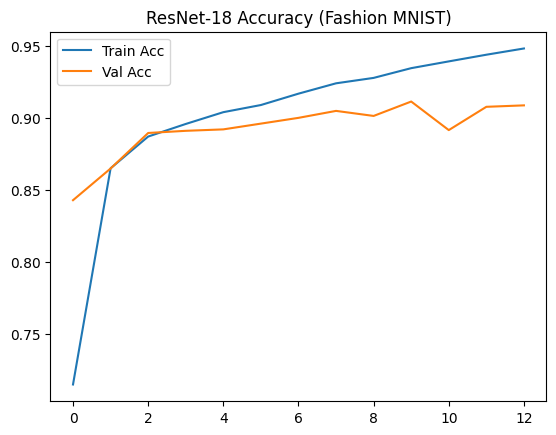

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Data Prep
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Build ResNet Helper & Model
def resnet_block(x, filters, downsample=False):
    shortcut = x
    stride = 2 if downsample else 1

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same')(x)

    if downsample:
        shortcut = layers.Conv2D(filters, (1, 1), strides=2, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

inputs = layers.Input(shape=(28, 28, 1))

# Initial Convolution
x = layers.Conv2D(64, (7, 7), padding='same', activation='relu')(inputs)

# 4 Stages of ResNet-18
x = resnet_block(x, 64)
x = resnet_block(x, 64)

x = resnet_block(x, 128, downsample=True)
x = resnet_block(x, 128)

x = resnet_block(x, 256, downsample=True)
x = resnet_block(x, 256)

x = resnet_block(x, 512, downsample=True)
x = resnet_block(x, 512)

# Global Average Pooling replaces flattening
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs, name="ResNet-18")

# 3. Train & Evaluate
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training ResNet-18 on Fashion MNIST...")
history = model.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.1, callbacks=[early_stop])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
model.summary()

# 4. Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ResNet-18 Accuracy (Fashion MNIST)')
plt.legend()
plt.show()